**CSI 4106 Introduction to Artificial Intelligence** <br/>
*Assignment 4: Heuristic Search*

# Identification

Name: Jamie Bly<br/>
Student Number:300231604

Name: <br/>
Student Number:

<br/>
<hr/>

## **Overview**

The **Traveling Salesman Problem (TSP)** is a foundational problem in optimization. Given a set of cities and pairwise distances, the objective is to compute the shortest possible tour that visits each city exactly once and returns to the start. Although the statement is simple, the search space grows factorially with the number of cities, making exhaustive search infeasible except for very small instances.

TSP is **NP-hard**, and no efficient algorithm is known for finding optimal solutions at scale. Its computational difficulty, together with its wide relevance in logistics, manufacturing, and circuit design, has made it a standard testbed for evaluating optimization techniques.

In this assignment, you will experiment with three approaches:

- **Greedy Algorithm** — a simple heuristic that constructs a tour by repeatedly making the best local choice.
- **Simulated Annealing (SA)** — a stochastic technique inspired by physical annealing, capable of escaping local minima.
- **Genetic Algorithm (GA)** — a population-based evolutionary strategy that iteratively refines candidate tours.

Your final deliverable is a **Jupyter Notebook** presenting your implementations, results, and observations for each method.

## **Learning Objectives**

- **Implement and experiment with** several search-based algorithms for the TSP.
- **Design** a principled method for choosing the initial temperature in Simulated Annealing.
- **Adapt and apply** a Genetic Algorithm to generate competitive TSP solutions.
- **Analyze and compare** the performance of all methods against known optimal tours.

## Submission 

- **Deadline:**
   - Submit your notebook by December 3, 11 PM.
- **Individual or Group Assignment:**
   - This assignment may be undertaken either individually (group of 1 student) or collaboratively in pairs (group of 2 students)
   - A group must submit a single joint submission.
   - Prior to submitting, it is necessary to **register your group** on Brightspace.
- **Submission Platform:**
   - Upload your submission to Brightspace under the Assignment section (Assignment 4).
- **Submission Format:**
   - Submit a copy of your notebook on Brightspace.

**Important Notice:** Ensure that your notebook executes without errors in Google Colab, which will be our standard reference environment. While you may choose to develop your notebook on a different platform, it is critical that your teaching assistant can run it in Colab without needing to install additional librairies or transfer data manually. Retain all execution results, including plots, within the notebook so that your teaching assistant can evaluate your work without needing to execute any cells.

## **Datasets**

The datasets used in this assignment come from the [TSPLIB GitHub repository](https://github.com/mastqe/tsplib), which provides standard benchmark instances for the Traveling Salesman Problem (TSP). All datasets are **Euclidean**, meaning distances between cities are computed directly from their coordinates using the Euclidean metric.

For your experiments, you will work with the **berlin52-24-4** and **st70-24** datasets. Each is a 24-city subset extracted from the corresponding full TSPLIB instance. Lower bounds on the tour cost for these subsets were computed using dynamic programming via the Held–Karp algorithm.

1. **berlin52-24-4**:
   - Number of Cities: 24
   - Optimal Solution Cost: **5890.92**

2. **st70-24-4**:
   - Number of Cities: 24
   - Optimal Solution Cost: **468.88**

These datasets are provided for evaluating the performance of your algorithms and compare your results against known optimal solutions. You can access the data on GitHub at the following location: [link](https://github.com/turcotte/csi4106-f25/tree/main/assignments-data/a4). The `extra` subfolder includes additional instances that may be useful as you work through the assignment.

For the optional bonus question, you will work with the following two datasets:

3. **berlin52**:
   - Number of Cities: 52
   - Description: A medium-sized dataset with realistic spatial distribution of cities.
   - Optimal Solution Cost: **7542**

4. **st70**:
   - Number of Cities: 70
   - Description: A slightly larger dataset with increased complexity.
   - Optimal Solution Cost: **675**

<br>
<hr/>

## **0. Given Code**

Here is a Jupyter Notebook featuring greedy algorithms and a genetic algorithm for solving the 0/1 knapsack problem.

<a target="_blank" href="https://colab.research.google.com/github/turcotte/csi4106-f25/blob/main/notebooks/lectures/20/knapsack.ipynb"> <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/> </a>

The following two lectures may be useful for this assignment.

- [Lecture 18](https://turcotte.xyz/teaching/csi-4106/lectures/18/slides.html) (simulated annealing)
- [Lecture 20](https://turcotte.xyz/teaching/csi-4106/lectures/20/slides.html) (genetic algorithm)

### 0.1. Imports

In [2]:
# Imports needed for the assignment go here:

import numpy as np
import requests
import time

### 0.2. Read the TSP Files

A function to read TSP files from a website.

In [3]:
def read_tsp(url):

    """
    Reads a .tsp file from a given URL and returns a NumPy array of coordinates.

    Parameters:
    -----------
    url : str
        The URL of the .tsp file.

    Returns:
    --------
    coordinates : ndarray
        A NumPy array of coordinates extracted from the .tsp file.

    Description:
    ------------
    This function fetches the content of a .tsp file from a specified URL and parses it to extract the city coordinates.
    It looks for the 'NODE_COORD_SECTION' in the file to start reading coordinates and stops when it reaches 'EOF'.
    The function handles potential errors by checking the HTTP response status and ensures that the coordinates are
    correctly parsed into floating-point numbers.

    Example:
    --------
    >>> url = 'https://raw.githubusercontent.com/turcotte/csi4106-f24/main/assignments-data/a4/berlin52-24-4.tsp'
    >>> coordinates = read_tsp(url)
    >>> print(coordinates)
    [[37.7692, -122.4443],
     [37.7689, -122.4240],
     ...
     [37.7793, -122.4192]]
    """

    try:
        # Fetch the content from the URL
        response = requests.get(url)
        response.raise_for_status()  # Raise an HTTPError for bad responses (4xx or 5xx)

        # Split the content into lines
        lines = response.text.splitlines()

        # Initialize a list to store the coordinates
        coordinates = []

        # Start reading after the NODE_COORD_SECTION line
        node_section = False
        for line in lines:
            line = line.strip()
            if line == "NODE_COORD_SECTION":
                node_section = True
                continue
            elif line == "EOF":
                break

            if node_section:
                # Split the line into parts and convert to float
                parts = line.split()
                if len(parts) >= 3:
                    # Some files include node indices, so we take the last two entries as coordinates
                    x, y = float(parts[-2]), float(parts[-1])
                    coordinates.append((x, y))

        # Convert the list of coordinates to a NumPy array
        return np.array(coordinates)

    except requests.exceptions.RequestException as e:
        print(f"An error occurred while fetching the TSP file: {e}")
        return None
    except ValueError as e:
        print(f"An error occurred while parsing the coordinates: {e}")
        return None

In [4]:
URL = 'https://raw.githubusercontent.com/turcotte/csi4106-f25/main/assignments-data/a4/'

berlin52_24_4 = read_tsp(URL + 'berlin52-24-4.tsp')
st70_24_4 = read_tsp(URL + 'st70-24-4.tsp')

The following function accepts the coordinates of the cities as input and outputs a distance matrix.

In [5]:
def get_distance_matrix(coordinates):

    """
        Takes coordinates input and returns distance matrix
        Input: coordinates (nn.array) - the input coordinates
        Output: distance_matrix (np.array) - the (num_cities x num_cities) distance matrix
    """

    num_cities = len(coordinates)
    distance_matrix = np.zeros((num_cities, num_cities))

    for i in range(num_cities):
        for j in range(num_cities):
            distance_matrix[i][j] = np.linalg.norm(coordinates[i] - coordinates[j])
            
    return distance_matrix 

#berlin_distance = get_distance_matrix(berlin52_24_4)
#print(berlin_distance)

The following functions may assist in visualizing results and debugging your programs.

In [6]:
import matplotlib.pyplot as plt

def plot_cities(coordinates, title="Cities in the Traveling Salesman Problem"):

    """
    Plots the given coordinates representing cities.
    
    Parameters:
    - coordinates: A 2D NumPy array of shape (n, 2) representing the (x, y) coordinates.
    - title: Title for the plot.
    """

    # Extract x and y coordinates
    x = coordinates[:, 0]
    y = coordinates[:, 1]

    plt.figure(figsize=(6, 6))

    # Plot the cities as red dots
    plt.scatter(x, y, c='red', zorder=2)

    # Annotate the cities with their indices
    for i, (xi, yi) in enumerate(zip(x, y)):
        plt.annotate(str(i + 1), (xi, yi), textcoords="offset points", xytext=(0, 5), ha='center')

    # Set title and labels
    plt.title(title)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.grid(True)
    plt.axis('equal')  # Equal scaling for x and y axes
    plt.show()

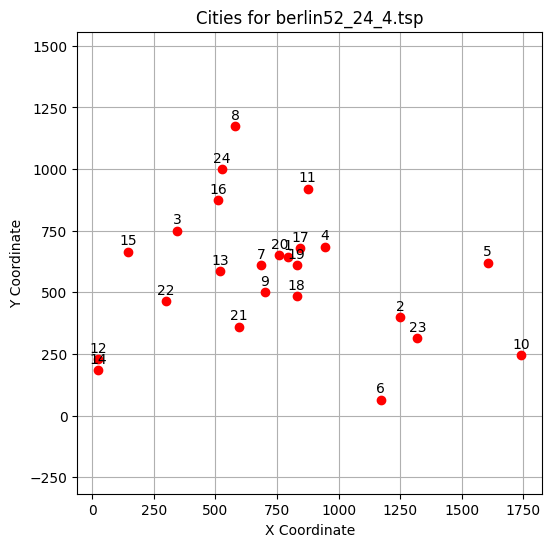

In [7]:
plot_cities(berlin52_24_4, title='Cities for berlin52_24_4.tsp')

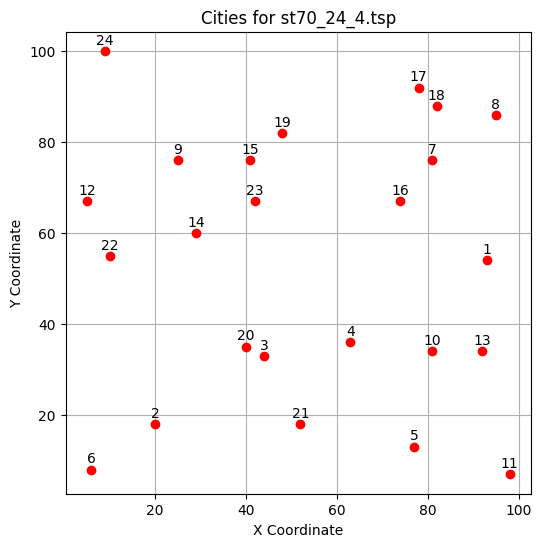

In [8]:
plot_cities(st70_24_4, title='Cities for st70_24_4.tsp')

In [9]:
def plot_tsp_path(coordinates, path=None, title="Traveling Salesman Problem"):

    """
    Plots the given coordinates and optionally a path for the TSP.
    
    Parameters:
    - coordinates: A 2D NumPy array of shape (n, 2) representing the (x, y) coordinates.
    - path: A list or array of indices representing the order of visiting the nodes. If None, nodes are connected in input order.
    - title: Title for the plot.
    """

    # Extract x and y coordinates
    x = coordinates[:, 0]
    y = coordinates[:, 1]

    plt.figure(figsize=(6, 6))

    # If a path is given, reorder the coordinates
    if path is not None:
        x = x[path]
        y = y[path]
    
    # Plot the nodes
    plt.scatter(x, y, c='red', zorder=2)

    # Annotate the nodes with their indices
    for i, (xi, yi) in enumerate(zip(x, y)):
        plt.annotate(str(i + 1), (xi, yi), textcoords="offset points", xytext=(0, 5), ha='center')

    # Plot the path
    plt.plot(x, y, 'b-', zorder=1)

    # If a path is provided, connect the last point to the first to complete the tour
    if path is not None:
        plt.plot([x[-1], x[0]], [y[-1], y[0]], 'b-', zorder=1)

    # Set title and labels
    plt.title(title)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.grid(True)
    plt.axis('equal')  # Equal scaling for x and y axes
    plt.show()

<hr/>

## 1. Implement the Algorithms

### 1.1. Implement a Greedy TSP Solver

The **nearest-neighbour heuristic** is a simple greedy strategy for constructing a feasible TSP tour.

-  Starting from a chosen city, the algorithm repeatedly selects the closest unvisited city until all cities have been visited, then returns to the starting point.
    - If two cities are equally close, ties may be broken arbitrarily.
-  This procedure is run once for every possible starting city, producing $N$ candidate tours for an instance with $N$ cities. The shortest of these $N$ tours is kept.
-  At each step, only valid moves are considered, ensuring that every tour visits each city exactly once.

Your implementation must return **both** the tour (as a list of city indices) **and** its total distance.

Although this heuristic is fast and always produces a valid tour, it offers no guarantee of optimality.


In [10]:
def greedy_tsp(distance_matrix, start_city=0):

    """
    Greedy algorithm for the Traveling Salesman Problem using the nearest neighbor heuristic.

    Args:
        distance_matrix (np.ndarray): Matrix of distances between cities.
        start_city (int): Index of the starting city.

    Returns:
        tuple: Best tour (list of city indices) and total distance.
    """
    tour = []
    total_distance = 0
    temp_distance_matrix = distance_matrix
    numCities =  len(temp_distance_matrix) 
    current_city = start_city    

    tour = [start_city]
 
    while(len(tour) != numCities):
        closest_city = -1
        for j in range(numCities):
            #print("Current City " + str(current_city) + ". Current J: " + str(j))
            if not(j in tour):
                if closest_city == -1 and j != current_city:
                    closest_city_distance = temp_distance_matrix[current_city][j]
                    closest_city = j
                elif temp_distance_matrix[current_city][j] < closest_city_distance and j != current_city:
                    closest_city = j
                    closest_city_distance = temp_distance_matrix[current_city][j]
        
        tour.append(closest_city)
        total_distance += closest_city_distance
        
        current_city = closest_city
    #adds distance back to start
    total_distance += distance_matrix[tour[len(tour)-1]][tour[0]]
    #print(str(tour) + " - " +str(total_distance))     
    return tour, total_distance

In [11]:
def greedy_tsp_do_all(distance_matrix):

    """
    Runs the greedy TSP heuristic once from every possible starting city
    and returns the best tour found.

    Args:
        distance_matrix (np.ndarray): Matrix of distances between cities.

    Returns:
        tuple: Best tour (list of city indices) and its total distance.
    """
    best_distance = 0
    best_tour = []
    # code goes here
    for starting_city in range(len(distance_matrix)):
        results = greedy_tsp(distance_matrix, starting_city)
        if best_distance == 0:
                best_distance=results[1]
                best_tour=results[0]
        elif results[1] < best_distance:
            best_distance=results[1]
            best_tour=results[0]


    return best_tour, best_distance

#print(greedy_tsp_do_all(berlin_distance))
#results = greedy_tsp_do_all(berlin_distance)
#plot_tsp_path(berlin52_24_4, results[0])

### 1.2. Implement a TSP Solver Using Simulated Annealing

In the Simulated Annealing (SA) implementation provided, you must **complete the `get_initial_temperature` method** by designing a strategy to select an appropriate starting temperature.

Your goal is to choose an initial temperature such that the **acceptance rate of proposed moves** (accepted / proposed) is approximately **60%–80%** when tested on a small batch of random moves.

**Suggestions:**

- **Sampling-based approach:**
  Generate a random tour and propose a set of random neighbour moves (e.g., 10–50). Select a temperature that yields an acceptance rate in the 60%–80% range.

- **Preliminary-run approach:**
  Perform a short preliminary run of the SA update loop (e.g., 20–100 moves), gradually reducing the temperature until the acceptance rate reaches 60%–80%. After determining this temperature, **restart the main SA run** from scratch using this value.

Use the same acceptance rule implemented in the provided SA code (`exp(-ΔE / T)` for worse moves).
Your temperature only needs to approximate the target range; exact matching is not required.


In [12]:
def calculate_total_distance(route, distance_matrix):

    """
    Calculate the total distance of a given route based on the distance matrix.

    Parameters:
    -----------
    route : ndarray
        An array representing the order of cities in the route (a permutation of city indices).
    distance_matrix : ndarray
        A square matrix where entry (i, j) represents the distance between city i and city j.

    Returns:
    --------
    total_distance : float
        The total distance of the route, including the return to the starting city.

    Description:
    ------------
    The function computes the sum of distances between consecutive cities in the route
    and adds the distance from the last city back to the first city to complete the tour.
    It assumes that the distance matrix is symmetric and non-negative.
    """
    
    total_distance = 0

    for i in range(len(route) - 1):
        total_distance += distance_matrix[route[i], route[i + 1]]

    total_distance += distance_matrix[route[-1], route[0]]  # Back to start

    return total_distance

In [13]:
def get_neighbor(route):    

    """
    Generate a neighboring solution by reversing a random segment of the route.

    Parameters:
    -----------
    route : ndarray
        An array representing the current route (a permutation of city indices).

    Returns:
    --------
    new_route : ndarray
        A new route obtained by reversing the segment between two randomly chosen indices.

    Description:
    ------------
    This method selects two random indices, `a` and `b`, within the route and reverses the
    segment between them (inclusive). It is commonly used in optimization algorithms like 
    Simulated Annealing to explore neighboring solutions in the search space.
    """

    a, b = np.random.randint(0, len(route), size=2)

    if a > b:
        a, b = b, a

    new_route = route.copy()
    new_route[a:b+1] = new_route[a:b+1][::-1]  # Reverse the segment between a and b
    
    return new_route

Finalize the implementation of the `get_initial_temperature` method. You may introduce additional parameters to the function definition as needed; ensure that any modifications are consistently reflected in all methods that invoke this function.

In [14]:
def get_initial_temperature(distance_matrix):

    """
    Estimate an initial temperature for the Simulated Annealing algorithm.

    Parameters:
    -----------
    distance_matrix : ndarray
        A square matrix where entry (i, j) represents the distance between city i and city j.

    Returns:
    --------
    initial_temp : float
        The estimated initial temperature to achieve the specified acceptance rate.

    Description:
    ------------
    The function:
        - Complete this section
    """

    # Code goes here
    percent = 1

    num_cities = len(distance_matrix)
    current_route = np.arange(num_cities)
    np.random.shuffle(current_route)
    current_cost = calculate_total_distance(current_route, distance_matrix)
    
    best_route = current_route.copy()
    best_cost = current_cost

    temperatures = []
    costs = []
    init_temp = -10
    flag = 0
    
    while flag < 10:
        accepted = 0
        temperature = init_temp
        for iteration in range(100):

            neighbor_route = get_neighbor(current_route)
            neighbor_cost = calculate_total_distance(neighbor_route, distance_matrix)
            
            # Accept neighbor if it's better, or with a probability if it's worse
            if neighbor_cost < current_cost or np.random.rand() < (neighbor_cost - current_cost) / temperature:
                current_route = neighbor_route
                current_cost = neighbor_cost
                accepted +=1
                

                if current_cost < best_cost:
                    best_route = current_route.copy()
                    best_cost = current_cost
                

            # Store temperature and cost for plotting
            temperatures.append(temperature)
            costs.append(current_cost)



            # Cool down the temperature
            temperature *= 0.995
        percent = accepted / 100
        if (0.6 <= percent <= 0.8):
            flag+=1
        elif not(0.6 <= percent <= 0.8):
            flag=0
        #print("Temperature: "+ str(init_temp)+ ".Percent: " + str(percent))
        init_temp += 1
            

 
    return init_temp

get_initial_temperature(get_distance_matrix(berlin52_24_4))

C:\Users\djbly\AppData\Local\Temp\ipykernel_27976\4238456776.py:47: RuntimeWarning: divide by zero encountered in scalar divide
  if neighbor_cost < current_cost or np.random.rand() < (neighbor_cost - current_cost) / temperature:
C:\Users\djbly\AppData\Local\Temp\ipykernel_27976\4238456776.py:47: RuntimeWarning: invalid value encountered in scalar divide
  if neighbor_cost < current_cost or np.random.rand() < (neighbor_cost - current_cost) / temperature:


411

In [15]:
def simulated_annealing(distance_matrix, initial_temp, cooling_rate, max_iterations):

    """
    Perform the Simulated Annealing algorithm to approximate a solution for the Traveling Salesman Problem (TSP).

    Parameters:
    -----------
    distance_matrix : ndarray
        A square matrix where entry (i, j) represents the distance between city i and city j.
    initial_temp : float
        The initial temperature for the annealing process.
    cooling_rate : float
        The rate at which the temperature decreases, typically a value between 0 and 1.
    max_iterations : int
        The maximum number of iterations to perform.

    Returns:
    --------
    best_route : ndarray
        The order of cities in the best (shortest) route found.
    best_cost : float
        The total distance of the best route.
    temperatures : list
        A list of temperature values at each iteration, useful for analysis or plotting.
    costs : list
        A list of route costs (distances) at each iteration, useful for analysis or plotting.

    Description:
    ------------
    Simulated Annealing (SA) is a probabilistic optimization algorithm inspired by the annealing process in metallurgy. 
    This implementation:
    - Starts with a random route and iteratively improves it.
    - Accepts worse solutions with a probability dependent on the temperature to escape local minima.
    - Reduces the temperature gradually to focus on exploitation as the algorithm progresses.
    - Returns the best route found along with intermediate data for analysis.

    """

    num_cities = len(distance_matrix)
    current_route = np.arange(num_cities)
    np.random.shuffle(current_route)
    current_cost = calculate_total_distance(current_route, distance_matrix)
    
    best_route = current_route.copy()
    best_cost = current_cost

    temperatures = []
    costs = []

    temperature = initial_temp

    for iteration in range(max_iterations):

        neighbor_route = get_neighbor(current_route)
        neighbor_cost = calculate_total_distance(neighbor_route, distance_matrix)
        
        # Accept neighbor if it's better, or with a probability if it's worse
        if neighbor_cost < current_cost or np.random.rand() < np.exp(-(neighbor_cost - current_cost) / temperature):
            current_route = neighbor_route
            current_cost = neighbor_cost

            if current_cost < best_cost:
                best_route = current_route.copy()
                best_cost = current_cost

        # Store temperature and cost for plotting
        temperatures.append(temperature)
        costs.append(current_cost)

        # Cool down the temperature
        temperature *= cooling_rate

    return best_route, best_cost, temperatures, costs

In [16]:
def simulated_annealing_do_n(distance_matrix, initial_temp, cooling_rate=0.995, max_iterations=1000, repeats=10):

    """
    Perform Simulated Annealing multiple times and return the best result across all runs.

    Parameters:
    -----------
    distance_matrix : ndarray
        A square matrix where entry (i, j) represents the distance between city i and city j.
    initial_temp : float
        The initial temperature for the annealing process.
    cooling_rate : float
        The rate at which the temperature decreases, typically a value between 0 and 1.
    max_iterations : int
        The maximum number of iterations for each Simulated Annealing run.
    repeats : int
        The number of times to repeat the Simulated Annealing process.

    Returns:
    --------
    best_tour : ndarray
        The order of cities in the best (shortest) tour found across all runs.
    best_distance : float
        The total distance of the best tour.
    best_temperatures : list
        A list of temperature values from the best run, useful for analysis or plotting.
    best_costs : list
        A list of route costs (distances) from the best run, useful for analysis or plotting.

    Notes:
    ------
    This method leverages the `simulated_annealing` function to perform individual optimization runs. 
    By repeating the process multiple times, it increases the likelihood of finding a globally optimal or near-optimal solution.
    """

    results = [
        simulated_annealing(distance_matrix, initial_temp, cooling_rate, max_iterations)
        for _ in range(repeats)
    ]

    # Find the best result by minimizing the distance
    best_tour, best_distance, best_temperatures, best_costs = min(results, key=lambda x: x[1])

    return best_tour, best_distance, best_temperatures, best_costs

The following functions may assist in visualizing results and debugging your programs.

In [17]:
def plot_temperature_and_cost(temperatures, costs):

    """
    Plot the temperature and cost values over iterations in a side-by-side graph.

    Parameters:
    -----------
    temperatures : list or ndarray
        A sequence of temperature values recorded at each iteration of an algorithm (e.g., Simulated Annealing).
    costs : list or ndarray
        A sequence of cost values (e.g., total distance or energy) recorded at each iteration.

    Description:
    ------------
    This function generates two subplots:
    1. **Temperature Over Iterations**: Plots how the temperature changes over time, which is useful for visualizing the cooling schedule in algorithms like Simulated Annealing.
    2. **Cost Over Iterations**: Plots the cost (e.g., total distance in TSP) at each iteration, showing how the solution improves over time.

    The plots are arranged side by side for easy comparison between the temperature schedule and the corresponding cost progression. The function adjusts the layout for better spacing and displays the combined figure.

    Example:
    --------
    >>> plot_temperature_and_cost(temperatures, costs)

    Notes:
    ------
    - Ensure that the lengths of `temperatures` and `costs` are equal, corresponding to the number of iterations.
    - Requires `matplotlib.pyplot` as `plt` to be imported before calling this function.
    """
    
    # Plot temperature and cost graphs
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(temperatures)
    plt.title("Temperature Over Iterations")
    plt.xlabel("Iteration")
    plt.ylabel("Temperature")

    plt.subplot(1, 2, 2)
    plt.plot(costs)
    plt.title("Cost Over Iterations")
    plt.xlabel("Iteration")
    plt.ylabel("Cost")

    plt.tight_layout()
    plt.show()

### 1.3. Implement a Solver for the TSP Using a Genetic Algorithm

A partial implementation of a **Genetic Algorithm (GA)** for the TSP is provided. Your task is to complete three key components while ensuring that all tours remain valid permutations of the cities.

The GA follows these steps:

1. **Initialization** – Generate an initial population of random valid tours.
2. **Evaluation** – Compute the total distance of each tour and assign fitness values.
3. **Elitism** – Copy the best individuals directly to the next generation.
4. **Selection** – Select parents (e.g., tournament or roulette-wheel selection).
5. **Crossover** – Produce children by recombining parents using a permutation-preserving crossover operator.
6. **Mutation** – Introduce variation by applying a mutation operator that maintains valid permutations.
7. **Replacement** – Form the next generation using elites and offspring.
8. Repeat steps 2–7 for a fixed number of generations.

You must implement the following three functions in the provided code:

* `evaluate_fitness(population, distance_matrix)`
* `crossover_operator(parent1, parent2)`
* `mutation(offspring, mutation_rate)`

Guidelines:

- You do **not** need to modify the provided docstrings; only implement the function bodies.
- **Fitness:** Compute fitness as the reciprocal of the route distance (e.g., `1 / (distance + 1e-6)`).
- **Crossover:** You may use any permutation-preserving crossover (e.g., OX, PMX, CX). The resulting child must be a valid tour.
- **Mutation:** Use any permutation-preserving mutation (e.g., swap, inversion, insertion).
- **Validity:** All individuals in every generation must remain valid permutations of the cities (each city appears exactly once).

In the implementation below, total_distances is used for reporting results, whereas fitness is used internally by the GA for selection.

In [18]:
def initialize_population(pop_size, num_cities):

    """
    Generate an initial population of random routes for a Genetic Algorithm.

    Parameters:
    -----------
    pop_size : int
        The number of individuals (routes) in the population.
    num_cities : int
        The number of cities in the Traveling Salesman Problem (TSP).

    Returns:
    --------
    population : ndarray
        A 2D array of shape (pop_size, num_cities), where each row represents
        a random permutation of city indices (a potential solution).

    Description:
    ------------
    This function initializes a population by creating `pop_size` random permutations
    of city indices, ensuring diversity in the initial solutions. Each individual
    represents a valid route for the TSP.
    """
    
    return np.array([np.random.permutation(num_cities) for _ in range(pop_size)])

Finalize the implementation of the `evaluate_fitness` method.

In [19]:
def evaluate_fitness(population, distance_matrix):

    """
    Evaluate the fitness of each individual in a population for a Genetic Algorithm.

    Parameters:
    -----------
    population : ndarray
        A 2D array where each row is an individual route (a permutation of city indices).
    distance_matrix : ndarray
        A square matrix where entry (i, j) represents the distance between city i and city j.

    Returns:
    --------
    fitness : ndarray
        A 1D array containing the fitness values for each individual in the population.
        Fitness is calculated as the reciprocal of the total distance of the route.
    total_distances : ndarray
        A 1D array containing the total distances of the routes for each individual.

    Description:
    ------------
    This function calculates:
    1. The total distance of each individual's route by summing the distances between consecutive cities,
       including the return to the starting city.
    2. The fitness value for each individual as the reciprocal of its total distance
       (with a small constant added to avoid division by zero).

    Fitness values are higher for shorter routes, encouraging better solutions during selection.
    """

    # Code goes here 
    fitness=[]
    total_distances=[]
      
    for row in population:
        current_city = row[0]
        current_distance = 0
        for next_city in row:
            current_distance+=distance_matrix[current_city][next_city]
            current_city = next_city
        current_distance += distance_matrix[current_city][row[0]]
        total_distances.append(current_distance)
        fitness.append(1 / (current_distance+0.1))
   # print("Fitness " + str(fitness))
    #print("Distnace " + str(total_distances))
    fitness = np.array(fitness)
    total_distances = np.array(total_distances)
        

    return fitness, total_distances

In [20]:
def tournament_selection(population, fitness, tournament_size):

    """
    Perform tournament selection to choose individuals for the next generation in a Genetic Algorithm.

    Parameters:
    -----------
    population : ndarray
        A 2D array where each row represents an individual (a potential solution).
    fitness : ndarray
        A 1D array containing the fitness values of the individuals in the population.
    tournament_size : int
        The number of individuals randomly selected for each tournament.

    Returns:
    --------
    selected_population : ndarray
        A 2D array of the same shape as `population`, containing the selected individuals
        for the next generation.

    Description:
    ------------
    Tournament selection works as follows:
    1. For each individual to be selected, randomly choose `tournament_size` participants from the population.
    2. Compare their fitness values and select the individual with the highest fitness.
    3. Repeat this process until a new population of the same size as the original is formed.

    This method balances exploitation (choosing the best individuals) with exploration (random selection
    of participants), allowing the algorithm to focus on high-quality solutions while maintaining diversity.
    """

    pop_size = population.shape[0]
    selected_indices = []
    
    for _ in range(pop_size):

        participants = np.random.choice(pop_size, tournament_size, replace=False)
        best = participants[np.argmax(fitness[participants])]
        selected_indices.append(best)

    return population[selected_indices]

In [21]:
def roulette_selection(population, fitness):

    """
    Perform roulette wheel selection to choose individuals for the next generation in a Genetic Algorithm.

    Parameters:
    -----------
    population : ndarray
        A 2D array where each row represents an individual (a potential solution).
    fitness : ndarray
        A 1D array containing the fitness values of the individuals in the population.

    Returns:
    --------
    selected_population : ndarray
        A 2D array of the same shape as `population`, containing the selected individuals
        for the next generation.

    Description:
    ------------
    Roulette wheel selection assigns selection probabilities to individuals based on their fitness:
    1. Compute the total fitness of the population.
    2. Normalize fitness values to create probabilities for each individual.
    3. Randomly select individuals from the population according to their probabilities.

    This method favors individuals with higher fitness, increasing their likelihood of being selected,
    while still allowing lower-fitness individuals a chance, maintaining genetic diversity.
    """

    total_fitness = np.sum(fitness)
    probabilities = fitness / total_fitness
    pop_size = population.shape[0]
    selected_indices = np.random.choice(pop_size, size=pop_size, p=probabilities)
    
    return population[selected_indices]

Finalize the implementation of the `crossover_operator` method.

In [22]:
def crossover_operator(parent1, parent2):

    """
    Perform crossover to produce an offspring from two parent solutions.

    Parameters:
    -----------
    parent1 : ndarray
        A 1D array representing the first parent (a permutation of city indices).
    parent2 : ndarray
        A 1D array representing the second parent (a permutation of city indices).

    Returns:
    --------
    child : ndarray
        A 1D array representing the offspring, combining genetic material from both parents.

    Description:
    ------------
        Complete the description.
    """
    # Code goes here
    num_genes = len(parent1)
    crossover_point = np.random.randint(1, num_genes)
    child = parent1[crossover_point:]
    child2 = parent2[:crossover_point]
    for x in child2:
        child = np.append(child, x)

    return child    

#print(crossover_operator([1,2,3,4,5], [6,7,8,9,10]))

In [23]:
def crossover(parents, crossover_rate):

    """
    Perform crossover on a population of parent solutions to produce offspring for the next generation.

    Parameters:
    -----------
    parents : ndarray
        A 2D array where each row represents a parent solution (a permutation of city indices).
    crossover_rate : float
        The probability of applying crossover to a pair of parents (value between 0 and 1).

    Returns:
    --------
    offspring : ndarray
        A 2D array of the same shape as `parents`, containing the offspring produced by crossover.

    Description:
    ------------
    This function generates offspring by pairing parents and applying a crossover operator:
    1. Randomly shuffle the parents to create random pairs.
    2. For each pair of parents, apply crossover with a probability defined by `crossover_rate`.
       - If crossover occurs, use `crossover_operator` to produce two children.
       - If not, directly copy the parents as the children.
    3. Continue until all parents are processed, ensuring the offspring population size matches the original.

    This approach maintains diversity while combining genetic material from pairs of parents to explore the search space.
    """

    num_parents, num_genes = parents.shape
    np.random.shuffle(parents)
    offspring = []

    for i in range(0, num_parents, 2):

        parent1 = parents[i]
        parent2 = parents[i + 1 if i + 1 < num_parents else 0]

        if np.random.rand() < crossover_rate:
            child1 = crossover_operator(parent1, parent2)
            child2 = crossover_operator(parent2, parent1)
        else:
            child1 = parent1.copy()
            child2 = parent2.copy()

        offspring.append(child1)
        offspring.append(child2)

    return np.array(offspring)

Finalize the implementation of the `mutation` method.

In [24]:

def mutation(offspring, mutation_rate):

    """
    Apply mutation to a population of offspring.

    Parameters:
    -----------
    offspring : ndarray
        A 2D array where each row represents an offspring solution (a permutation of city indices).
    mutation_rate : float
        The probability of applying mutation to each offspring (value between 0 and 1).

    Returns:
    --------
    offspring : ndarray
        A 2D array of the same shape as the input, with mutations applied to some individuals.

    Description:
    ------------
        Complete the description.
    """

    # Code goes here
    new_offspring = []
    for child in offspring:
        new_child=[]
        if np.random.rand() < mutation_rate:
            mutation_index_1 = mutation_index_2 =  np.random.randint(0, len(child)-1)
            while mutation_index_2 == mutation_index_1:
                mutation_index_2 = np.random.randint(0, len(child)-1)
            for i in range(0,len(child)):
                if i == mutation_index_1:
                    new_child.append(child[mutation_index_2])
                elif i == mutation_index_2:
                    new_child.append(child[mutation_index_1])
                else:
                    new_child.append(child[i])
            new_offspring.append(new_child)
            offspring = new_offspring
    


    return offspring

#print(mutation([[1,2,3,4,5,6], [2,2,2,3,4,5,5,5], [00,11,22,33,44,55,66,77,88,99,1010]], 100))

In [25]:
def elitism(population, fitness, elite_size):

    """
    Retain the top-performing individuals in a population based on their fitness.

    Parameters:
    -----------
    population : ndarray
        A 2D array where each row represents an individual solution.
    fitness : ndarray
        A 1D array containing the fitness values of the individuals in the population.
    elite_size : int
        The number of top-performing individuals to retain.

    Returns:
    --------
    elite_population : ndarray
        A 2D array containing the `elite_size` individuals with the highest fitness.

    Description:
    ------------
    This function implements elitism, which ensures that the best solutions are carried
    over to the next generation without modification:
    1. Sort the individuals in the population by their fitness values.
    2. Select the indices of the top `elite_size` individuals.
    3. Return the corresponding elite individuals from the population.

    Elitism helps preserve high-quality solutions, improving the stability and convergence
    of a Genetic Algorithm.
    """

    elite_indices = np.argsort(fitness)[-elite_size:]

    return population[elite_indices]

In [26]:
def genetic_algorithm(distance_matrix, pop_size=100, num_generations=200, crossover_rate=0.8,
                      mutation_rate=0.05, elite_percent=0.02, selection_type='tournament', tournament_size=3):

    """
    Solve the Traveling Salesman Problem (TSP) using a Genetic Algorithm (GA).

    Parameters:
    -----------
    distance_matrix : ndarray
        A square matrix where entry (i, j) represents the distance between city i and city j.
    pop_size : int, optional
        The size of the population (default: 100).
    num_generations : int, optional
        The number of generations to evolve (default: 200).
    crossover_rate : float, optional
        The probability of applying crossover to a pair of parents (default: 0.8).
    mutation_rate : float, optional
        The probability of mutating an offspring (default: 0.05).
    elite_percent : float, optional
        The fraction of the population to preserve as elites (default: 0.02).
    selection_type : str, optional
        The selection method to use ('tournament' or 'roulette', default: 'tournament').
    tournament_size : int, optional
        The number of participants in each tournament (used only for tournament selection, default: 3).

    Returns:
    --------
    best_solution : ndarray
        The order of cities in the best route found.
    best_distance : float
        The total distance of the best route.
    average_distance_history : list
        The average total distance of the population at each generation.
    best_distance_history : list
        The best total distance in the population at each generation.

    Description:
    ------------
    This function implements a Genetic Algorithm (GA) to find an approximate solution to the TSP:
    1. **Initialization**: Create a random initial population of routes.
    2. **Evaluation**: Compute the fitness of individuals based on their route distances.
    3. **Elitism**: Preserve the top-performing individuals for the next generation.
    4. **Selection**: Choose parents using tournament or roulette wheel selection.
    5. **Crossover**: Generate offspring by combining parents using a crossover operator.
    6. **Mutation**: Introduce diversity by randomly mutating offspring.
    7. **Replacement**: Combine elites and offspring to form the next generation.
    8. Repeat steps 2-7 for a fixed number of generations, tracking the best and average distances.

    At the end of the evolution process, the function returns the best solution found, along with metrics
    for performance analysis over generations.

    Notes:
    ------
    - The algorithm ensures the population size remains constant across generations.
    - `selection_type` determines the strategy used for selecting parents (tournament is the default).
    - The function can be customized further with different crossover and mutation operators.
    """

    num_cities = distance_matrix.shape[0]
    elite_size = max(1, int(pop_size * elite_percent))
    population = initialize_population(pop_size, num_cities)
    
    average_distance_history = []
    best_distance_history = []
    
    for generation in range(num_generations):

        fitness, total_distances = evaluate_fitness(population, distance_matrix)
        
        # Track average and best distances
        average_distance = np.mean(total_distances)
        best_distance = np.min(total_distances)
        average_distance_history.append(average_distance)
        best_distance_history.append(best_distance)

        # Elitism
        elites = elitism(population, fitness, elite_size)

        # Selection
        if selection_type == 'tournament':
            parents = tournament_selection(population, fitness, tournament_size)
        elif selection_type == 'roulette':
            parents = roulette_selection(population, fitness)
        else:
            raise ValueError("Invalid selection type")

        # Crossover
        offspring = crossover(parents, crossover_rate)

        # Mutation
        offspring = mutation(offspring, mutation_rate)

        # Create new population
        population = np.vstack((elites, offspring))

        # Ensure population size
        if population.shape[0] > pop_size:
            population = population[:pop_size]
        elif population.shape[0] < pop_size:
            num_new_individuals = pop_size - population.shape[0]
            new_individuals = initialize_population(num_new_individuals, num_cities)
            population = np.vstack((population, new_individuals))

    # Final evaluation to return the best solution
    fitness, total_distances = evaluate_fitness(population, distance_matrix)
    best_index = np.argmax(fitness)
    best_solution = population[best_index]
    best_distance = total_distances[best_index]

    return best_solution, best_distance, average_distance_history, best_distance_history

In [27]:
def genetic_algorithm_do_n(distance_matrix, pop_size=100, num_generations=200, crossover_rate=0.8,
                           mutation_rate=0.05, elite_percent=0.02, selection_type='tournament',
                           tournament_size=3, repeats=10):

    """
    Run the Genetic Algorithm multiple times and return the best solution across all runs.

    Parameters:
    -----------
    distance_matrix : ndarray
        A square matrix where entry (i, j) represents the distance between city i and city j.
    pop_size : int, optional
        The size of the population (default: 100).
    num_generations : int, optional
        The number of generations to evolve in each run (default: 200).
    crossover_rate : float, optional
        The probability of applying crossover to a pair of parents (default: 0.8).
    mutation_rate : float, optional
        The probability of mutating an offspring (default: 0.05).
    elite_percent : float, optional
        The fraction of the population to preserve as elites (default: 0.02).
    selection_type : str, optional
        The selection method to use ('tournament' or 'roulette', default: 'tournament').
    tournament_size : int, optional
        The number of participants in each tournament (used only for tournament selection, default: 3).
    repeats : int, optional
        The number of times to repeat the Genetic Algorithm (default: 10).

    Returns:
    --------
    best_tour : ndarray
        The order of cities in the best route found across all runs.
    best_distance : float
        The total distance of the best route across all runs.
    best_averages : list
        The average total distances of the population at each generation for the best run.
    best_bests : list
        The best total distances at each generation for the best run.

    Description:
    ------------
    This function runs the Genetic Algorithm multiple times to improve the chances of finding a globally
    optimal solution. For each run, the results are compared, and the best route and corresponding metrics
    are retained. This approach leverages the stochastic nature of Genetic Algorithms to explore the solution
    space more thoroughly.
    """

    results = [
        genetic_algorithm(distance_matrix, pop_size, num_generations, crossover_rate,
                          mutation_rate, elite_percent, selection_type, tournament_size)
        for _ in range(repeats)
    ]
    
    best_tour, distance, averages, bests = min(results, key=lambda x: x[1])  # Minimize by total distance

    return best_tour, distance, averages, bests

The following function may assist in visualizing results and debugging your programs.

In [28]:
def plot_fitness_over_generations(avg_distances, best_distances):

    """
    Plot the average and best distances over generations in a Genetic Algorithm.

    Parameters:
    -----------
    avg_distances : list or ndarray
        A sequence of average distances of the population at each generation.
    best_distances : list or ndarray
        A sequence of the best (minimum) distances found at each generation.

    Description:
    ------------
    This function generates a line plot to visualize how the average and best distances
    evolve over the generations during the execution of a Genetic Algorithm. It helps in
    understanding the convergence behavior and effectiveness of the algorithm.

    - **X-axis**: Represents the generation number.
    - **Y-axis**: Represents the distance (cost) values.
    - **Curves**:
        - *Average Distance*: Shows the average performance of the population at each generation.
        - *Best Distance*: Highlights the best solution found up to that generation.

    Example:
    --------
    >>> plot_fitness_over_generations(average_distance_history, best_distance_history)

    Notes:
    ------
    - Ensure that `avg_distances` and `best_distances` are of the same length, corresponding to the number of generations.
    - Requires `matplotlib.pyplot` as `plt` to be imported before calling this function.
    - Call `plt.show()` if the plot does not display automatically in your environment.
    """
    
    # Plot the fitness over generations
    generations = range(1, len(avg_distances) + 1)
    plt.figure(figsize=(6, 6))

    # Plot average and best distances over generations
    plt.plot(generations, avg_distances, label='Average Distance')
    plt.plot(generations, best_distances, label='Best Distance')
    plt.xlabel('Generation')
    plt.ylabel('Distance')
    plt.title('Distance Over Generations')
    plt.legend()
    plt.show()

<hr/>

## 2. Experimentation

### **2.1. Execute Each Algorithm on Both Datasets**

You must evaluate the **Greedy Algorithm**, **Simulated Annealing (SA)**, and **Genetic Algorithm (GA)** on **both** datasets:
`berlin52_24_4` and `st70_24_4`.

Your goal is to measure (1) solution quality and (2) execution time in a way that is consistent, comparable, and statistically meaningful.

#### **A. Definition of a “Run” (important)**

A **run** means **one complete execution of an algorithm**, producing:

* one tour (valid TSP solution),
* one tour length (cost),
* one execution time.

**For each algorithm**, one run is defined as follows:

##### Greedy Algorithm — One Run

A single run consists of:

* executing the greedy heuristic **once from every possible starting city**,
* selecting the **shortest** tour among these.

This full process counts as **one run**.

##### Simulated Annealing (SA) — One Run

A single run consists of:

* one full execution of the SA algorithm
  (starting from an initial tour, using your temperature schedule, running for the number of iterations *you* choose).

##### Genetic Algorithm (GA) — One Run

A single run consists of:

* one full execution of the GA
  (initial population → several generations → final best tour).

**You must explicitly state**:

* how many iterations you use for SA,
* how many generations you use for GA,
* your reasoning (briefly).

The numbers **do not** need to match between SA and GA.

#### **B. Number of Independent Runs**

For each algorithm **and** each dataset:

- Perform **10 independent runs**.
- Each run must start from a different random initialization (for SA and GA).
- The purpose of 10 runs is to average out randomness and measure **execution time** reliably.

#### **C. Measurements Collected for Each Run**

For **every one of the 10 runs** (for every algorithm × dataset):

Record:

1. **Best Path Cost**
   The tour length produced by that run.

2. **Execution Time**
   Time from the start of the run to completion of the run.

This gives you:

- 10 costs + 10 times for Greedy on berlin52_24_4
- 10 costs + 10 times for SA on berlin52_24_4

- 60 runs × 2 metrics overall.


#### **D. Reporting Your Results**

For each algorithm and dataset:

- Compute the **average** tour cost across the 10 runs.
- Compute the **average** execution time across the 10 runs.
- You may also report additional statistics (e.g., min, max, standard deviation), but this is optional.

Be consistent and clearly state:

- your SA iteration count,
- your GA generation count,
- your mutation/crossover parameters (briefly),
- any other assumptions.

#### **E. Important Clarification**

- The **number of runs** (10) is used to measure **variability** and **execution time**.
- The **number of iterations (SA)** and **number of generations (GA)** are part of the **algorithm design**, not part of repetition.
- SA and GA **do not need to use the same number** of iterations/generations.
  - They are different algorithms with different dynamics.
- What matters is that your choices are **reasonable**, **clearly stated**, and **used consistently**.



## My Decisions and Reasoning

For this testing, I decided that I wanted to go with some larger parameters for the SA and GA algorithms, to narrow down on the maximum more. I ended up deciding to set GA to generations = 250,
as it turned out to be a good balance between precision and computational efficiency. For the SA, max_iteration=2500, I wanted to try to keep it even with what I changed for the GA (25% increase),
but went with 50% due to the algorithm being less computationally intensive. 

For all other parameters, I decided to leave them as the defaults to explore the effects of changing the number of generations and iterations in the SA and GA Algorithms.

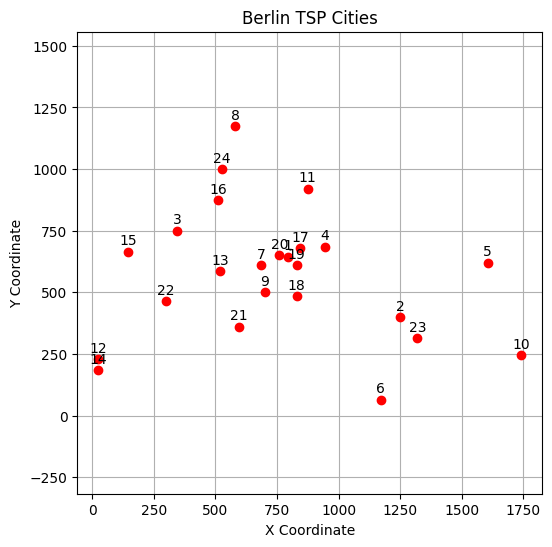

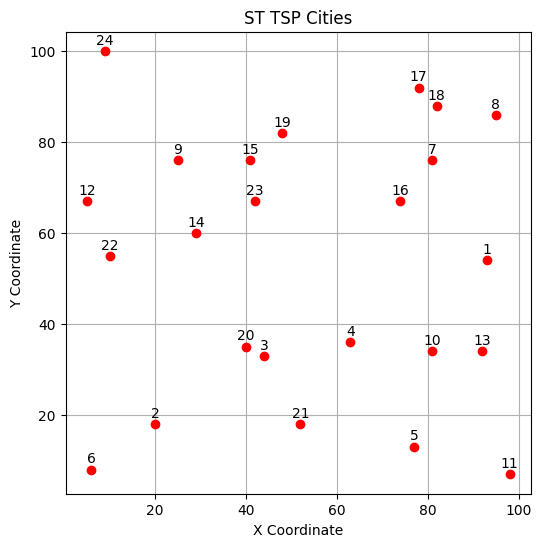

Dataset: Berlin. Iteration: 1


C:\Users\djbly\AppData\Local\Temp\ipykernel_27976\4238456776.py:47: RuntimeWarning: divide by zero encountered in scalar divide
  if neighbor_cost < current_cost or np.random.rand() < (neighbor_cost - current_cost) / temperature:


Dataset: Berlin. Iteration: 2


C:\Users\djbly\AppData\Local\Temp\ipykernel_27976\4238456776.py:47: RuntimeWarning: invalid value encountered in scalar divide
  if neighbor_cost < current_cost or np.random.rand() < (neighbor_cost - current_cost) / temperature:


Dataset: Berlin. Iteration: 3
Dataset: Berlin. Iteration: 4
Dataset: Berlin. Iteration: 5
Dataset: Berlin. Iteration: 6
Dataset: Berlin. Iteration: 7
Dataset: Berlin. Iteration: 8
Dataset: Berlin. Iteration: 9
Dataset: Berlin. Iteration: 10
Dataset: ST. Iteration: 1
Dataset: ST. Iteration: 2
Dataset: ST. Iteration: 3
Dataset: ST. Iteration: 4
Dataset: ST. Iteration: 5
Dataset: ST. Iteration: 6
Dataset: ST. Iteration: 7
Dataset: ST. Iteration: 8
Dataset: ST. Iteration: 9
Dataset: ST. Iteration: 10
Default Parameters Run
  Dataset  Iteration         Cost  Execution Time
0  berlin        1.0  7029.605933        0.005217
0  berlin        2.0  7029.605933        0.004848
0  berlin        3.0  7029.605933        0.004729
0  berlin        4.0  7029.605933        0.004652
0  berlin        5.0  7029.605933        0.004833
0  berlin        6.0  7029.605933        0.004570
0  berlin        7.0  7029.605933        0.004066
0  berlin        8.0  7029.605933        0.004193
0  berlin        9.0  702

C:\Users\djbly\AppData\Local\Temp\ipykernel_27976\4238456776.py:47: RuntimeWarning: divide by zero encountered in scalar divide
  if neighbor_cost < current_cost or np.random.rand() < (neighbor_cost - current_cost) / temperature:
C:\Users\djbly\AppData\Local\Temp\ipykernel_27976\4238456776.py:47: RuntimeWarning: invalid value encountered in scalar divide
  if neighbor_cost < current_cost or np.random.rand() < (neighbor_cost - current_cost) / temperature:


Dataset: Berlin. Iteration: 2
Dataset: Berlin. Iteration: 3
Dataset: Berlin. Iteration: 4
Dataset: Berlin. Iteration: 5
Dataset: Berlin. Iteration: 6
Dataset: Berlin. Iteration: 7
Dataset: Berlin. Iteration: 8
Dataset: Berlin. Iteration: 9
Dataset: Berlin. Iteration: 10
Dataset: ST. Iteration: 1
Dataset: ST. Iteration: 2
Dataset: ST. Iteration: 3
Dataset: ST. Iteration: 4
Dataset: ST. Iteration: 5
Dataset: ST. Iteration: 6
Dataset: ST. Iteration: 7
Dataset: ST. Iteration: 8
Dataset: ST. Iteration: 9
Dataset: ST. Iteration: 10
  Dataset  Iteration         Cost  Execution Time
0  berlin        1.0  7029.605933        0.005449
0  berlin        2.0  7029.605933        0.005215
0  berlin        3.0  7029.605933        0.004196
0  berlin        4.0  7029.605933        0.004455
0  berlin        5.0  7029.605933        0.004790
0  berlin        6.0  7029.605933        0.004539
0  berlin        7.0  7029.605933        0.004122
0  berlin        8.0  7029.605933        0.004439
0  berlin        9

In [29]:
# code goes here
import pandas as pd

def get_elapsed_time(start_time, end_time):
    elapsed_time = end_time - start_time
    return elapsed_time

data ={'Dataset':[],
        'Iteration': [],
        'Cost': [],
        'Execution Time': []}

greedy_table_berlin = greedy_table_st = sa_table_berlin = sa_table_st = ga_table_berlin = ga_table_st = pd.DataFrame(data)

plot_cities(berlin52_24_4, "Berlin TSP Cities")
plot_cities(st70_24_4, "ST TSP Cities")
berlin_distance_matrix = get_distance_matrix(berlin52_24_4)
st_distance_matrix = get_distance_matrix(st70_24_4)

#Default Parameters
for i in range (1, 11):
    print("Dataset: Berlin. Iteration: " + str(i))
    greedy_start = time.time()
    greedy_results = greedy_tsp_do_all(berlin_distance_matrix)
    greedy_end= time.time()
    sa_start = time.time()
    sa_results = simulated_annealing_do_n(berlin_distance_matrix, get_initial_temperature(berlin_distance_matrix), max_iterations=1500)
    sa_end= time.time()
    ga_start = time.time()
    ga_results = genetic_algorithm_do_n(berlin_distance_matrix, num_generations=250)
    ga_end= time.time()

    new_row = pd.DataFrame({"Dataset":["berlin"],"Iteration" : [i], "Cost": [greedy_results[1]], "Execution Time": [get_elapsed_time(greedy_start, greedy_end)] })
    greedy_table_berlin = pd.concat([greedy_table_berlin, new_row])
    new_row = pd.DataFrame({"Dataset":["berlin"],"Iteration" : [i], "Cost": [sa_results[1]], "Execution Time": [get_elapsed_time(sa_start, sa_end)] })
    sa_table_berlin = pd.concat([sa_table_berlin, new_row])
    new_row = pd.DataFrame({"Dataset":["berlin"],"Iteration" : [i], "Cost": [ga_results[1]], "Execution Time": [get_elapsed_time(ga_start, ga_end)] })
    ga_table_berlin = pd.concat([ga_table_berlin, new_row])

for i in range (1, 11):
    print("Dataset: ST. Iteration: " + str(i))
    greedy_start = time.time()
    greedy_results = greedy_tsp_do_all(st_distance_matrix)
    greedy_end= time.time()
    sa_start = time.time()
    sa_results = simulated_annealing_do_n(st_distance_matrix, get_initial_temperature(st_distance_matrix), max_iterations=1500)
    sa_end= time.time()
    ga_start = time.time()
    ga_results = genetic_algorithm_do_n(st_distance_matrix, num_generations=250)
    ga_end= time.time()

    new_row = pd.DataFrame({"Dataset":["st"],"Iteration" : [i], "Cost": [greedy_results[1]], "Execution Time": [get_elapsed_time(greedy_start, greedy_end)] })
    greedy_table_st = pd.concat([greedy_table_st, new_row])
    new_row = pd.DataFrame({"Dataset":["st"],"Iteration" : [i], "Cost": [sa_results[1]], "Execution Time": [get_elapsed_time(sa_start, sa_end)] })
    sa_table_st = pd.concat([sa_table_st, new_row])
    new_row = pd.DataFrame({"Dataset":["st"],"Iteration" : [i], "Cost": [ga_results[1]], "Execution Time": [get_elapsed_time(ga_start, ga_end)] })
    ga_table_st = pd.concat([ga_table_st, new_row])

print("Default Parameters Run")
print(greedy_table_berlin)
print("Average Cost: " + str(greedy_table_berlin['Cost'].mean()))
print("Min Cost" + str(greedy_table_berlin['Cost'].min()))
print("Average Execution Tome: " + str(greedy_table_berlin['Execution Time'].mean()))
print(sa_table_berlin)
print("Average Cost: " + str(sa_table_berlin['Cost'].mean()))
print("Min Cost" + str(sa_table_berlin['Cost'].min()))
print("Average Execution Time: " + str(sa_table_berlin['Execution Time'].mean()))
print(ga_table_berlin)
print("Average Cost: " + str(ga_table_berlin['Cost'].mean()))
print("Min Cost" + str(ga_table_berlin['Cost'].min()))
print("Average Execution Time: " + str(ga_table_berlin['Execution Time'].mean()))


print(greedy_table_st)
print("Average Cost: " + str(greedy_table_st['Cost'].mean()))
print("Min Cost" + str(greedy_table_st['Cost'].min()))
print("Average Execution Tome: " + str(greedy_table_st['Execution Time'].mean()))
print(sa_table_st)
print("Average Cost: " + str(sa_table_st['Cost'].mean()))
print("Min Cost" + str(sa_table_st['Cost'].min()))
print("Average Execution Time: " + str(sa_table_st['Execution Time'].mean()))
print(ga_table_st)
print("Average Cost: " + str(ga_table_st['Cost'].mean()))
print("Min Cost" + str(ga_table_st['Cost'].min()))
print("Average Execution Time: " + str(ga_table_st['Execution Time'].mean()))
results_data = ({
    "dataset": ["Berlin", "Berlin", "Berlin", "st", "st", "st"],
    "Algorithm": ["Greedy", "SA", "GA","Greedy", "SI", "GA"],
    "Average Cost": [str(greedy_table_berlin['Cost'].mean()), str(sa_table_berlin['Cost'].mean()), str(ga_table_berlin['Cost'].mean()), str(greedy_table_st['Cost'].mean()), str(sa_table_st['Cost'].mean()), str(ga_table_st['Cost'].mean())],
    "Average Execution Time": [str(greedy_table_berlin['Execution Time'].mean()), str(sa_table_berlin['Execution Time'].mean()), str(ga_table_berlin['Execution Time'].mean()), str(greedy_table_st['Execution Time'].mean()), str(sa_table_st['Execution Time'].mean()), str(ga_table_st['Execution Time'].mean())],
    "Min Cost": [str(greedy_table_berlin['Cost'].min()), str(sa_table_berlin['Cost'].min()), str(ga_table_berlin['Cost'].min()), str(greedy_table_st['Cost'].min()), str(sa_table_st['Cost'].min()), str(ga_table_st['Cost'].min())]
})


df = pd.DataFrame(results_data)
print(df)


greedy_table_berlin = greedy_table_st = sa_table_berlin = sa_table_st = ga_table_berlin = ga_table_st = pd.DataFrame(data)
#Specified Parameters
for i in range (1, 11):
    print("Dataset: Berlin. Iteration: " + str(i))
    greedy_start = time.time()
    greedy_results = greedy_tsp_do_all(berlin_distance_matrix)
    greedy_end= time.time()
    sa_start = time.time()
    sa_results = simulated_annealing_do_n(berlin_distance_matrix, get_initial_temperature(berlin_distance_matrix), max_iterations=1500)
    sa_end= time.time()
    ga_start = time.time()
    ga_results = genetic_algorithm_do_n(berlin_distance_matrix, num_generations=250)
    ga_end= time.time()

    new_row = pd.DataFrame({"Dataset":["berlin"],"Iteration" : [i], "Cost": [greedy_results[1]], "Execution Time": [get_elapsed_time(greedy_start, greedy_end)] })
    greedy_table_berlin = pd.concat([greedy_table_berlin, new_row])
    new_row = pd.DataFrame({"Dataset":["berlin"],"Iteration" : [i], "Cost": [sa_results[1]], "Execution Time": [get_elapsed_time(sa_start, sa_end)] })
    sa_table_berlin = pd.concat([sa_table_berlin, new_row])
    new_row = pd.DataFrame({"Dataset":["berlin"],"Iteration" : [i], "Cost": [ga_results[1]], "Execution Time": [get_elapsed_time(ga_start, ga_end)] })
    ga_table_berlin = pd.concat([ga_table_berlin, new_row])

for i in range (1, 11):
    print("Dataset: ST. Iteration: " + str(i))
    greedy_start = time.time()
    greedy_results = greedy_tsp_do_all(st_distance_matrix)
    greedy_end= time.time()
    sa_start = time.time()
    sa_results = simulated_annealing_do_n(st_distance_matrix, get_initial_temperature(st_distance_matrix), max_iterations=1500)
    sa_end= time.time()
    ga_start = time.time()
    ga_results = genetic_algorithm_do_n(st_distance_matrix, num_generations=250)
    ga_end= time.time()

    new_row = pd.DataFrame({"Dataset":["st"],"Iteration" : [i], "Cost": [greedy_results[1]], "Execution Time": [get_elapsed_time(greedy_start, greedy_end)] })
    greedy_table_st = pd.concat([greedy_table_st, new_row])
    new_row = pd.DataFrame({"Dataset":["st"],"Iteration" : [i], "Cost": [sa_results[1]], "Execution Time": [get_elapsed_time(sa_start, sa_end)] })
    sa_table_st = pd.concat([sa_table_st, new_row])
    new_row = pd.DataFrame({"Dataset":["st"],"Iteration" : [i], "Cost": [ga_results[1]], "Execution Time": [get_elapsed_time(ga_start, ga_end)] })
    ga_table_st = pd.concat([ga_table_st, new_row])

#Specified Parameters Run (SA:Max_iteration=1500, GA: num_generations=250)
print(greedy_table_berlin)
print("Average Cost: " + str(greedy_table_berlin['Cost'].mean()))
print("Min Cost" + str(greedy_table_berlin['Cost'].min()))
print("Average Execution Tome: " + str(greedy_table_berlin['Execution Time'].mean()))
print(sa_table_berlin)
print("Average Cost: " + str(sa_table_berlin['Cost'].mean()))
print("Min Cost" + str(sa_table_berlin['Cost'].min()))
print("Average Execution Time: " + str(sa_table_berlin['Execution Time'].mean()))
print(ga_table_berlin)
print("Average Cost: " + str(ga_table_berlin['Cost'].mean()))
print("Min Cost" + str(ga_table_berlin['Cost'].min()))
print("Average Execution Time: " + str(ga_table_berlin['Execution Time'].mean()))


print(greedy_table_st)
print("Average Cost: " + str(greedy_table_st['Cost'].mean()))
print("Min Cost" + str(greedy_table_st['Cost'].min()))
print("Average Execution Tome: " + str(greedy_table_st['Execution Time'].mean()))
print(sa_table_st)
print("Average Cost: " + str(sa_table_st['Cost'].mean()))
print("Min Cost" + str(sa_table_st['Cost'].min()))
print("Average Execution Time: " + str(sa_table_st['Execution Time'].mean()))
print(ga_table_st)
print("Average Cost: " + str(ga_table_st['Cost'].mean()))
print("Min Cost" + str(ga_table_st['Cost'].min()))
print("Average Execution Time: " + str(ga_table_st['Execution Time'].mean()))
results_data = ({
    "dataset": ["Berlin", "Berlin", "Berlin", "st", "st", "st"],
    "Algorithm": ["Greedy", "SA", "GA","Greedy", "SI", "GA"],
    "Average Cost": [str(greedy_table_berlin['Cost'].mean()), str(sa_table_berlin['Cost'].mean()), str(ga_table_berlin['Cost'].mean()), str(greedy_table_st['Cost'].mean()), str(sa_table_st['Cost'].mean()), str(ga_table_st['Cost'].mean())],
    "Average Execution Time": [str(greedy_table_berlin['Execution Time'].mean()), str(sa_table_berlin['Execution Time'].mean()), str(ga_table_berlin['Execution Time'].mean()), str(greedy_table_st['Execution Time'].mean()), str(sa_table_st['Execution Time'].mean()), str(ga_table_st['Execution Time'].mean())],
    "Min Cost": [str(greedy_table_berlin['Cost'].min()), str(sa_table_berlin['Cost'].min()), str(ga_table_berlin['Cost'].min()), str(greedy_table_st['Cost'].min()), str(sa_table_st['Cost'].min()), str(ga_table_st['Cost'].min())]
})


df = pd.DataFrame(results_data)
print(df)


**Hint**: Utilize the following method to measure elapsed time.

In [36]:
print(greedy_table_berlin)
print("Average Cost: " + str(greedy_table_berlin['Cost'].mean()))
print("Min Cost" + str(greedy_table_berlin['Cost'].min()))
print("Average Execution Tome: " + str(greedy_table_berlin['Execution Time'].mean()))
print(sa_table_berlin)
print("Average Cost: " + str(sa_table_berlin['Cost'].mean()))
print("Min Cost" + str(sa_table_berlin['Cost'].min()))
print("Average Execution Time: " + str(sa_table_berlin['Execution Time'].mean()))
print(ga_table_berlin)
print("Average Cost: " + str(ga_table_berlin['Cost'].mean()))
print("Min Cost" + str(ga_table_berlin['Cost'].min()))
print("Average Execution Time: " + str(ga_table_berlin['Execution Time'].mean()))


print(greedy_table_st)
print("Average Cost: " + str(greedy_table_st['Cost'].mean()))
print("Min Cost" + str(greedy_table_st['Cost'].min()))
print("Average Execution Tome: " + str(greedy_table_st['Execution Time'].mean()))
print(sa_table_st)
print("Average Cost: " + str(sa_table_st['Cost'].mean()))
print("Min Cost" + str(sa_table_st['Cost'].min()))
print("Average Execution Time: " + str(sa_table_st['Execution Time'].mean()))
print(ga_table_st)
print("Average Cost: " + str(ga_table_st['Cost'].mean()))
print("Min Cost" + str(ga_table_st['Cost'].min()))
print("Average Execution Time: " + str(ga_table_st['Execution Time'].mean()))
results_data = ({
    "dataset": ["Berlin", "Berlin", "Berlin", "st", "st", "st"],
    "Algorithm": ["Greedy", "SA", "GA","Greedy", "SI", "GA"],
    "Average Cost": [str(greedy_table_berlin['Cost'].mean()), str(sa_table_berlin['Cost'].mean()), str(ga_table_berlin['Cost'].mean()), str(greedy_table_st['Cost'].mean()), str(sa_table_st['Cost'].mean()), str(ga_table_st['Cost'].mean())],
    "Average Execution Time": [str(greedy_table_berlin['Execution Time'].mean()), str(sa_table_berlin['Execution Time'].mean()), str(ga_table_berlin['Execution Time'].mean()), str(greedy_table_st['Execution Time'].mean()), str(sa_table_st['Execution Time'].mean()), str(ga_table_st['Execution Time'].mean())],
    "Min Cost": [str(greedy_table_berlin['Cost'].min()), str(sa_table_berlin['Cost'].min()), str(ga_table_berlin['Cost'].min()), str(greedy_table_st['Cost'].min()), str(sa_table_st['Cost'].min()), str(ga_table_st['Cost'].min())]
})

df = pd.DataFrame(results_data)
print(df)
def get_elapsed_time(start_time, end_time):
    elapsed_time = end_time - start_time
    return elapsed_time

  Dataset  Iteration         Cost  Execution Time
0  berlin        1.0  7029.605933        0.004494
0  berlin        2.0  7029.605933        0.004490
0  berlin        3.0  7029.605933        0.005127
0  berlin        4.0  7029.605933        0.005053
0  berlin        5.0  7029.605933        0.004218
0  berlin        6.0  7029.605933        0.004393
0  berlin        7.0  7029.605933        0.004658
0  berlin        8.0  7029.605933        0.004150
0  berlin        9.0  7029.605933        0.004205
0  berlin       10.0  7029.605933        0.004107
Average Cost: 7029.605933260265
Min Cost7029.605933260265
Average Execution Tome: 0.004489469528198242
  Dataset  Iteration         Cost  Execution Time
0  berlin        1.0  6493.744049        1.242591
0  berlin        2.0  6089.738491        1.267502
0  berlin        3.0  6653.924964        1.494321
0  berlin        4.0  6086.053510        1.191041
0  berlin        5.0  6331.720188        1.438051
0  berlin        6.0  6265.786802        1.1842

### 2.2. Results Discussion

Write a structured discussion of your results for the `berlin52_24_4` and `st70_24_4` datasets. Address each of the points below. (A good target is about one short paragraph per numbered item.)

1. **Performance Comparison**

   - Compare the **average best path costs** achieved by each algorithm on both datasets. Use the known optimal or lower-bound cost as a reference and state which algorithm most closely approaches it.
   - Discuss any differences between the two datasets. Comment on whether the size or structure of the dataset appears to influence the results.

2. **Consistency**

   - Assess the variability of results across the 10 runs for each algorithm (for example, using min/max, standard deviation, or visual inspection of distributions).
   - Note any trends, such as algorithms that consistently produce higher costs, or algorithms whose results fluctuate strongly from run to run.

3. **Efficiency**

   - Compare the **average execution times** of the algorithms on each dataset. Identify which algorithm is fastest and which is slowest.
   - Comment explicitly on trade-offs between computational efficiency and solution quality (e.g., “Algorithm A is slower but tends to find shorter tours than Algorithm B”).

4. **Strengths and Weaknesses**

   - Highlight the main strengths of each algorithm (e.g., speed, quality of solutions, robustness to randomness).
   - Discuss limitations or weaknesses you observed, such as sensitivity to initialization, tendency to get stuck in local optima, or high computational cost for certain parameter choices.

5. **Insights and Implications**

   - Summarize the key lessons from your experiments. What do your results suggest about the suitability of each algorithm for solving the TSP in this setting?
   - Briefly discuss how you expect each algorithm to scale to larger instances. You may answer this conceptually; you do not need to run additional datasets.

Enhance your discussion with tables and figures where appropriate. For example, you may include:
- tables of average cost and average time per algorithm and dataset;
- histograms or boxplots of tour costs across runs;
- bar charts comparing average execution times.

Answer here:

### Performance Comparison
Looking at the difference between the two test sets I did (one with defaults and one with the specified parameters). It is quite evident to see that while Simulated Annealing is superior to the GA model and approaches an optimal solution more closely, as the number of generations increases in the GA Model, the difference between the two results decreases. 

### Consistency:
I found the GA to be noticeably less consistent on the Berlin set than on the st dataset. I believe this is due to the st dataset cities being more "normally" distributed, whereas the Berlin dataset is more random, and often clumped. In the case of the st dataset, a wrong decision has a higher average cost, since there is more distance on average between the cities. 

On the other side, the GA minimum is often less than that of the SA algorithm, which further shows the algorithm's inconsistency in this scenario.

### Efficiency
The efficiency of the algorithms is another obvious difference, as you can clearly see that the Simulated Annealing algorithm is considerably more efficient than the Genetic algorithm, showing that specified parameters to takes more than 13 times the amount of time per run.


### Strengths and Weaknesses
There are very obvious pros and cons to each algorithm. I shall go one at a time:

Greedy: Very simple to construct, and will find a solution if one is possible. Computationally efficient. Weakness is that it doesn't guarantee an optimal, or even good, solution.

Simulated Annealing: This algorithm was very consistent on these datasets, finding a good solution with relatively minimal overhead. The only weakness is that it doesn't have the same possibility to find an even more optimal solution, and is less robust to randomness (can get stuck).

Genetic Algorithm: Very good at finding more optimal solutions, especially as you increase the parameters (number of generations, population, etc.), but therein lies its weakness. To find a good solution that approaches the optimal reliably requires a lot of computational overhead. The more overhead, the more consistent and optimal, and the less the more inconsistent.

### Insights and Implications

From my results today, here are my main takeaways:

Greedy: Should be used to find a solution when the quality doesn't matter, with minimal overhead.

Simulated Annealing: Should be used to find a good solution with little overhead. It can find a solution approaching optimal, especially on continuous functions, but it is less robust to randomness than the GA and can get stuck at local-optima more than it as well.

Genetic Algorithm: Should be used when finding a solution that approaches the optimal is required, and there are no limitations on overhead. It converges slower than a SA algoithm, though it is better suited to handle randomness than simulated annealing, which makes it better suited to handle more complex, random datasets or problems.



<hr/>

## 3. Optional Bonus Question

This question is optional and offers up to **5 bonus points** for running your existing implementations of **Simulated Annealing (SA)** and **Genetic Algorithm (GA)** on the **full** TSPLIB datasets: `berlin52` and `st70`.

Use the same algorithmic implementations as in the main assignment. You may adjust **parameters only** (e.g., number of iterations/generations, population size, mutation rate, temperature schedule). Do **not** modify the algorithmic logic.

The known optimal tour costs are:

- **berlin52**: 7542  
- **st70**: 675  

Use these values to evaluate your results.

### Grading Rubric

- **5 points**  
  Both SA **and** GA reach the **optimal solution** (exact best-known cost) on **both** datasets.

- **4 points**  
  Both SA **and** GA produce solutions satisfying  
$$
  \frac{\textrm{your\_cost} - \textrm{optimal\_cost}}{\textrm{optimal\_cost}} \le 0.05
$$
  i.e., within **5%** of optimal on **both** datasets.

- **3 points**  
  Both SA **and** GA outperform the **best greedy solution** (best over all starting cities) on **both** datasets.

- **2 points**  
  **Either** SA **or** GA reaches the **optimal solution** on **both** datasets.

- **1 point**  
  **Either** SA **or** GA outperforms the best greedy solution on **both** datasets.

### What to Submit

Include the following in your write-up:

- The parameter values you used (iterations, generations, population size, mutation rate, initial temperature, etc.).  
- The final tour cost obtained by SA on each dataset.  
- The final tour cost obtained by GA on each dataset.  
- A short explanation of how you verified your results (e.g., comparison to optimal or greedy baseline).  
- Any plots or tables you find helpful (optional).

Include the necessary **source code** below your explanation.


In [105]:
# Code goes here

# Evaluation Criteria (78)

- **Overall Effort in the Report (3)**

	- The writing should be clear and descriptive, allowing readers to readily comprehend the actions taken, the methods employed, and the rationale behind them.
	- Distinguish clearly between the narrative text, code, and results to enhance readability.
	- Use tables and/or graphs to visually compare different methodologies effectively.
	- Ensure the report contains sufficient detail to enable the reproducibility of the findings.

- **Code Quality (3)**

	- Clear structure, descriptive names, short functions.
    - One command re-creates results, random seeds fixed, output paths managed, no need for manual intervention.
    - Dependencies clearly documented.
    - Comprehensive validations and graceful error handling.

- **Exploratory Analysis (75)**
 
    1. **Greedy Algorithm Implementation (15)**
    1. **Simulated Annealing Implementation (10)**
    1. **Genetic Algorithm Implementation (25)**
    1. **Execution (10)**
    1. **Analysis of Results (10)**

- **Resources and References (2)**

    - Cite any part of your code that is sourced from websites, including tutorial sites or Stack Overflow.
    - Reference any theory or algorithms utilized that are found in books, slides, or tutorials.

# Resources

As previously stated, it is important to properly attribute any portions of your code that are sourced from external materials, such as websites, textbooks, or other resources.

In contemporary software development, artificial intelligence (AI) is increasingly utilized by programmers to boost productivity, a trend expected to persist. To remain competitive in the job market, it is advantageous to integrate these technologies into your skill set. Nonetheless, it is crucial to thoroughly comprehend the underlying concepts on which evaluations are based, given that AI tools may not be accessible during in-person assessments.

If you use AI assistance, it is essential to meticulously document all interactions. Your report should specify the tools and their versions, accompanied by a complete transcript of these interactions. Most AI platforms automatically log conversations, so it is advisable to initiate a new conversation specifically for the assignment and consistently use this thread throughout your work. Ensure that this conversation remains focused exclusively on the assignment. Include the transcript of this conversation in the reference section of your Jupyter Notebook.

### Resources I used:
https://www.geeksforgeeks.org/artificial-intelligence/what-is-simulated-annealing/

https://machinelearningmastery.com/simulated-annealing-from-scratch-in-python/

https://www.w3schools.com/python

https://www.w3schools.com/python/pandas

### AI Disclaimer

I did not use any AI resources for this project. 

# Questions

- Please direct any questions you have to the Assignment topic within the discussion forum on Brightspace. This approach is highly encouraged, as it facilitates collective learning by enabling all students to access both the questions and the responses provided by the teaching assistants. 
- If necessary, you may also email one of the four teaching assistants directly, although this method is less preferred.
